In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import sys; sys.path.insert(0, '../..')
from feature_engineering import add_trend_features

## 1-day Horizon

In [3]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [4]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 1

# Supervised setup: features at time t predict BAA10Y at time t+H.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where either the current spread (needed for naive baseline)
# or the future spread (the target) is NaN.
mask = y_future.notna() & y_now.notna()
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

Horizon H = 1 day(s)
Samples: 11686  (1990-01-02 → 2025-12-31)


In [5]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end   = pd.Timestamp(f"{year}-09-30")
    test_start  = pd.Timestamp(f"{year}-10-01")
    test_end    = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':      year,
            'X_train':   X.loc[train_mask],
            'y_train':   y.loc[train_mask],
            'X_test':    X.loc[test_mask],
            'y_test':    y.loc[test_mask],
            'y_t_test':  y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train 1990-01-02 → 2000-09-30 (3559 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train 1990-01-02 → 2002-09-30 (4014 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train 1990-01-02 → 2003-09-30 (4379 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train 1995-10-01 → 2025-09-30 (9862 rows) | test 2025-10-01 → 2025-12-31 (92 rows)


Best n_estimators (boosting rounds): 78



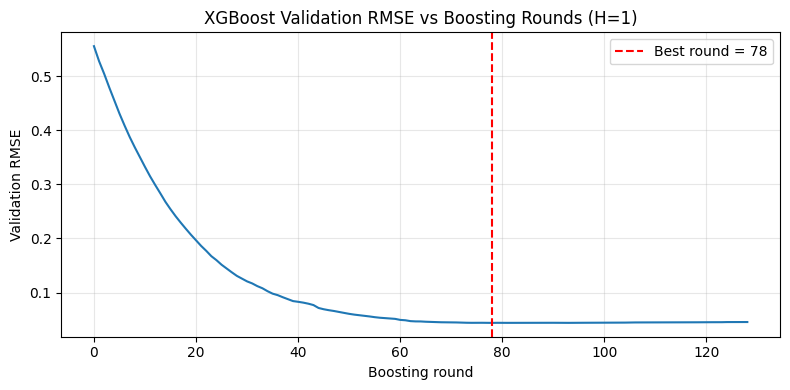

In [6]:
# Sweep n_estimators (number of boosting rounds) on the first fold using
# early stopping — the XGBoost equivalent of the RF OOB sweep.
# We use a small validation slice (last 20% of training) to drive early stopping.

X_sweep = folds[0]['X_train']
y_sweep = folds[0]['y_train']

val_cut  = int(len(X_sweep) * 0.80)
X_tr_sw  = X_sweep.iloc[:val_cut]
y_tr_sw  = y_sweep.iloc[:val_cut]
X_val_sw = X_sweep.iloc[val_cut:]
y_val_sw = y_sweep.iloc[val_cut:]

sweep_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
)
sweep_model.fit(
    X_tr_sw, y_tr_sw,
    eval_set=[(X_val_sw, y_val_sw)],
    verbose=False,
)

best_n = sweep_model.best_iteration
print(f"Best n_estimators (boosting rounds): {best_n}\n")

# Plot validation RMSE curve
results = sweep_model.evals_result()
val_rmse = results['validation_0']['rmse']

plt.figure(figsize=(8, 4))
plt.plot(val_rmse)
plt.axvline(best_n, color='red', linestyle='--', label=f'Best round = {best_n}')
plt.xlabel('Boosting round')
plt.ylabel('Validation RMSE')
plt.title(f'XGBoost Validation RMSE vs Boosting Rounds (H={H})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
fold_results = []
all_y_test   = []
all_y_pred   = []
all_y_curr   = []

for fold in folds:
    xgb_fold = xgb.XGBRegressor(
        n_estimators=best_n,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_fold.fit(fold['X_train'], fold['y_train'])

    y_pred_fold = pd.Series(xgb_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true      = fold['y_test']
    y_curr      = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir   = np.sign(y_true.values  - y_curr.values)
    pred_dir  = np.sign(y_pred_fold.values - y_curr.values)
    non_flat  = act_dir != 0
    dir_acc   = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_XGB': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)

    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R\u00b2={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all   = pd.concat(all_y_test)
y_pred_all   = pd.concat(all_y_pred)
y_curr_all   = pd.concat(all_y_curr)
results_df   = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE XGB':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_XGB'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

2000: MAE=0.1014 (naive=0.0148)  RMSE=0.1371  R²=-0.287  DirAcc=39.62%
2002: MAE=0.1959 (naive=0.0174)  RMSE=0.2417  R²=-0.857  DirAcc=54.90%
2003: MAE=0.0216 (naive=0.0109)  RMSE=0.0264  R²= 0.806  DirAcc=55.10%
2004: MAE=0.0166 (naive=0.0075)  RMSE=0.0222  R²= 0.925  DirAcc=44.19%
2005: MAE=0.0088 (naive=0.0066)  RMSE=0.0127  R²= 0.783  DirAcc=51.35%
2006: MAE=0.0125 (naive=0.0063)  RMSE=0.0153  R²= 0.874  DirAcc=45.45%
2007: MAE=0.0268 (naive=0.0197)  RMSE=0.0512  R²= 0.963  DirAcc=50.91%
2009: MAE=0.0363 (naive=0.0143)  RMSE=0.0420  R²= 0.859  DirAcc=57.41%
2010: MAE=0.0412 (naive=0.0186)  RMSE=0.0489  R²= 0.940  DirAcc=63.64%
2011: MAE=0.0269 (naive=0.0149)  RMSE=0.0312  R²= 0.895  DirAcc=47.27%
2012: MAE=0.0244 (naive=0.0116)  RMSE=0.0287  R²= 0.881  DirAcc=66.67%
2013: MAE=0.0155 (naive=0.0099)  RMSE=0.0207  R²= 0.969  DirAcc=61.36%
2014: MAE=0.0184 (naive=0.0124)  RMSE=0.0233  R²= 0.904  DirAcc=34.04%
2015: MAE=0.0269 (naive=0.0117)  RMSE=0.0309  R²= 0.539  DirAcc=54.55%
2016: 

In [8]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat       = actual_direction != 0
dir_acc_xgb    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive  = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  XGB model : {dir_acc_xgb:.2%}")
print(f"  Naive     : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

Overall directional accuracy across all folds (excl. flat moves, n=1187):
  XGB model : 50.88%
  Naive     : 0.00%

Breakdown by actual direction:
  Actual UP   ( 532 days): XGB correct 45.30%
  Actual DOWN ( 655 days): XGB correct 55.42%


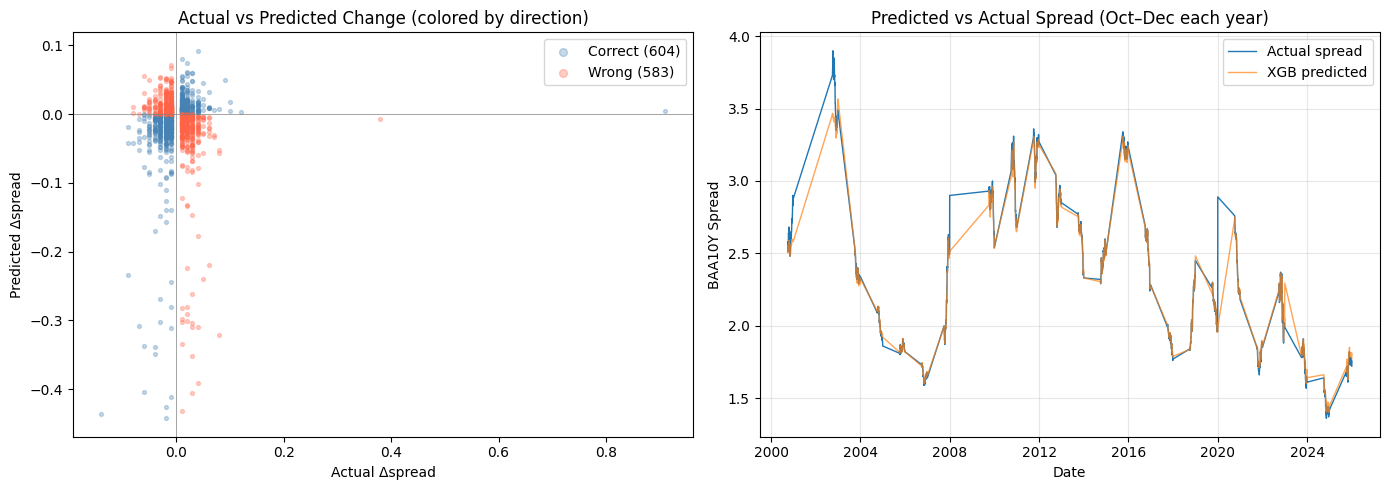

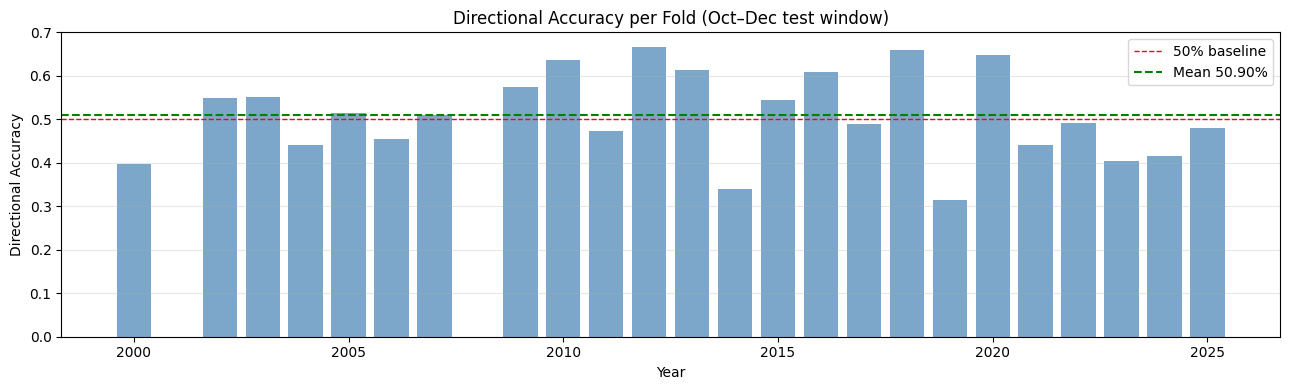

In [9]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',     label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual Δspread')
ax.set_ylabel('Predicted Δspread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='XGB predicted', lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct–Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

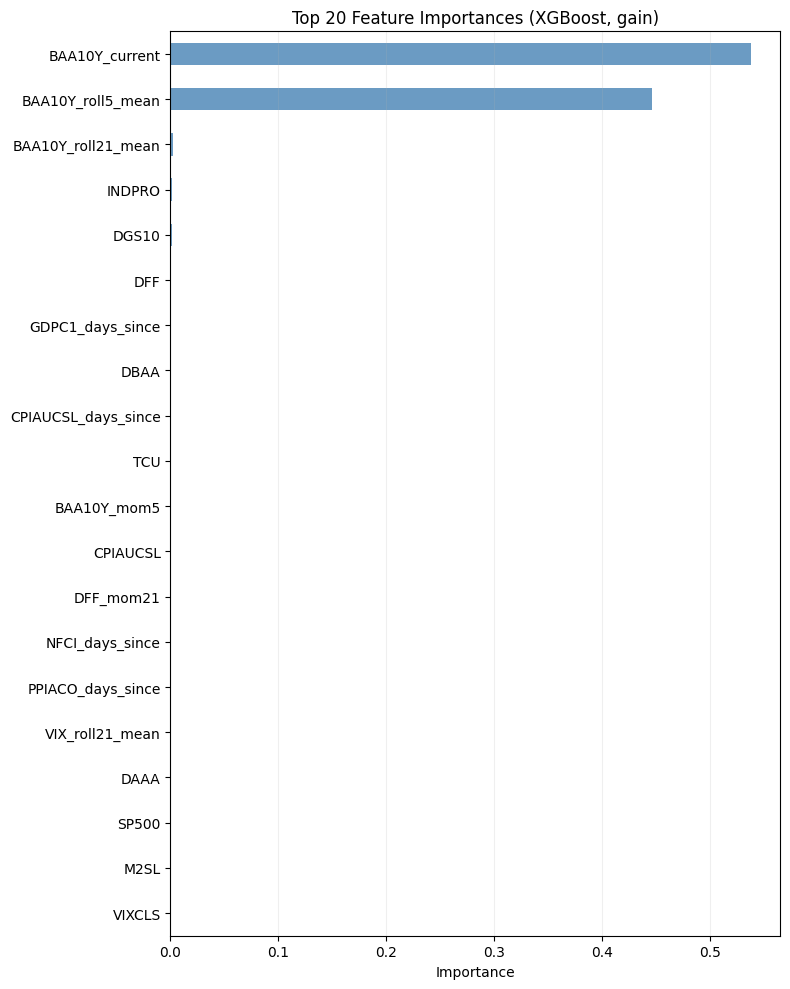

In [10]:
xgb_full = xgb.XGBRegressor(
    n_estimators=best_n,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_full.fit(X, y)

importances = pd.Series(xgb_full.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
importances.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 20 Feature Importances (XGBoost, gain)')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

## 7-day Horizon

In [11]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [12]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 7

# Supervised setup: features at time t predict BAA10Y at time t+H.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where either the current spread (needed for naive baseline)
# or the future spread (the target) is NaN.
mask = y_future.notna() & y_now.notna()
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

Horizon H = 7 day(s)
Samples: 11680  (1990-01-02 → 2025-12-25)


In [13]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end   = pd.Timestamp(f"{year}-09-30")
    test_start  = pd.Timestamp(f"{year}-10-01")
    test_end    = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':      year,
            'X_train':   X.loc[train_mask],
            'y_train':   y.loc[train_mask],
            'X_test':    X.loc[test_mask],
            'y_test':    y.loc[test_mask],
            'y_t_test':  y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train 1990-01-02 → 2000-09-30 (3559 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train 1990-01-02 → 2002-09-30 (4014 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train 1990-01-02 → 2003-09-30 (4379 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train 1995-10-01 → 2025-09-30 (9862 rows) | test 2025-10-01 → 2025-12-25 (86 rows)


Best n_estimators (boosting rounds): 124



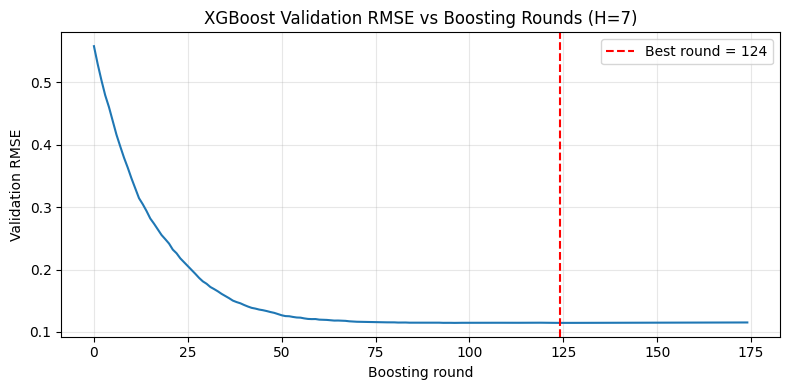

In [14]:
# Sweep n_estimators (number of boosting rounds) on the first fold using
# early stopping — the XGBoost equivalent of the RF OOB sweep.
# We use a small validation slice (last 20% of training) to drive early stopping.

X_sweep = folds[0]['X_train']
y_sweep = folds[0]['y_train']

val_cut  = int(len(X_sweep) * 0.80)
X_tr_sw  = X_sweep.iloc[:val_cut]
y_tr_sw  = y_sweep.iloc[:val_cut]
X_val_sw = X_sweep.iloc[val_cut:]
y_val_sw = y_sweep.iloc[val_cut:]

sweep_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
)
sweep_model.fit(
    X_tr_sw, y_tr_sw,
    eval_set=[(X_val_sw, y_val_sw)],
    verbose=False,
)

best_n = sweep_model.best_iteration
print(f"Best n_estimators (boosting rounds): {best_n}\n")

# Plot validation RMSE curve
results = sweep_model.evals_result()
val_rmse = results['validation_0']['rmse']

plt.figure(figsize=(8, 4))
plt.plot(val_rmse)
plt.axvline(best_n, color='red', linestyle='--', label=f'Best round = {best_n}')
plt.xlabel('Boosting round')
plt.ylabel('Validation RMSE')
plt.title(f'XGBoost Validation RMSE vs Boosting Rounds (H={H})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
fold_results = []
all_y_test   = []
all_y_pred   = []
all_y_curr   = []

for fold in folds:
    xgb_fold = xgb.XGBRegressor(
        n_estimators=best_n,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_fold.fit(fold['X_train'], fold['y_train'])

    y_pred_fold = pd.Series(xgb_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true      = fold['y_test']
    y_curr      = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir   = np.sign(y_true.values  - y_curr.values)
    pred_dir  = np.sign(y_pred_fold.values - y_curr.values)
    non_flat  = act_dir != 0
    dir_acc   = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_XGB': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)

    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R\u00b2={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all   = pd.concat(all_y_test)
y_pred_all   = pd.concat(all_y_pred)
y_curr_all   = pd.concat(all_y_curr)
results_df   = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE XGB':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_XGB'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

2000: MAE=0.1683 (naive=0.0618)  RMSE=0.2101  R²=-1.339  DirAcc=39.56%
2002: MAE=0.1840 (naive=0.0743)  RMSE=0.2237  R²=-0.605  DirAcc=65.88%
2003: MAE=0.0613 (naive=0.0353)  RMSE=0.0700  R²=-1.048  DirAcc=37.04%
2004: MAE=0.0605 (naive=0.0243)  RMSE=0.0759  R²= 0.247  DirAcc=34.21%
2005: MAE=0.0186 (naive=0.0222)  RMSE=0.0242  R²= 0.137  DirAcc=63.10%
2006: MAE=0.0247 (naive=0.0241)  RMSE=0.0306  R²= 0.372  DirAcc=64.29%
2007: MAE=0.1384 (naive=0.1029)  RMSE=0.1881  R²= 0.614  DirAcc=36.26%
2009: MAE=0.0771 (naive=0.0593)  RMSE=0.0887  R²= 0.588  DirAcc=58.75%
2010: MAE=0.0679 (naive=0.0777)  RMSE=0.0867  R²= 0.840  DirAcc=63.74%
2011: MAE=0.0574 (naive=0.0548)  RMSE=0.0828  R²= 0.207  DirAcc=54.12%
2012: MAE=0.0973 (naive=0.0529)  RMSE=0.1069  R²=-1.029  DirAcc=43.33%
2013: MAE=0.0869 (naive=0.0411)  RMSE=0.1114  R²= 0.240  DirAcc=22.09%
2014: MAE=0.0535 (naive=0.0458)  RMSE=0.0677  R²=-0.145  DirAcc=63.33%
2015: MAE=0.0328 (naive=0.0351)  RMSE=0.0413  R²=-0.189  DirAcc=62.50%
2016: 

In [16]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat       = actual_direction != 0
dir_acc_xgb    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive  = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  XGB model : {dir_acc_xgb:.2%}")
print(f"  Naive     : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

Overall directional accuracy across all folds (excl. flat moves, n=2041):
  XGB model : 51.05%
  Naive     : 0.00%

Breakdown by actual direction:
  Actual UP   ( 853 days): XGB correct 61.66%
  Actual DOWN (1188 days): XGB correct 43.43%


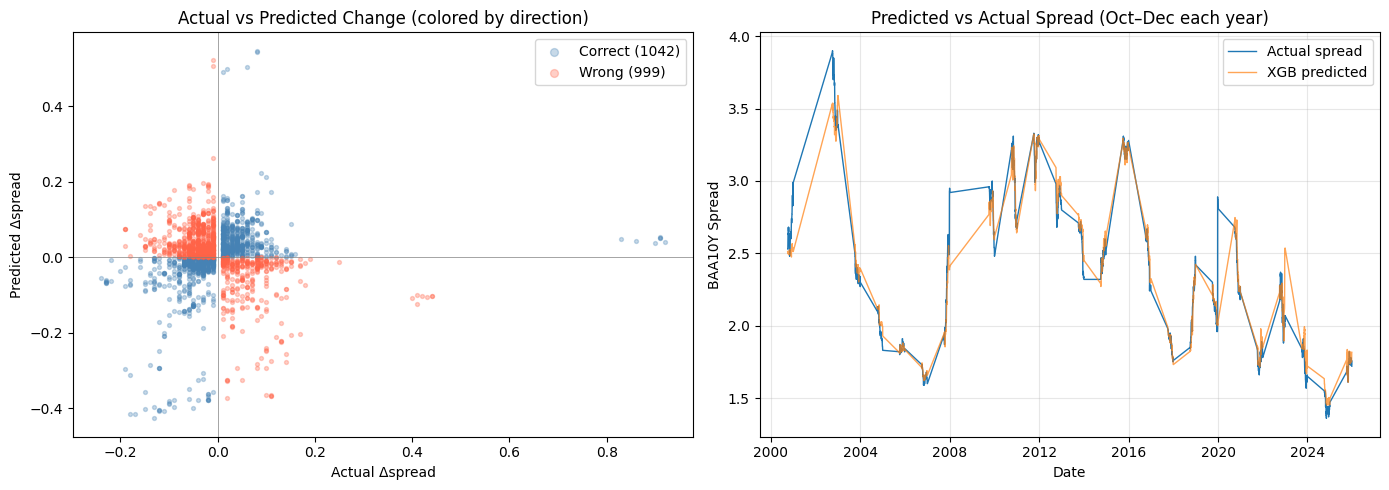

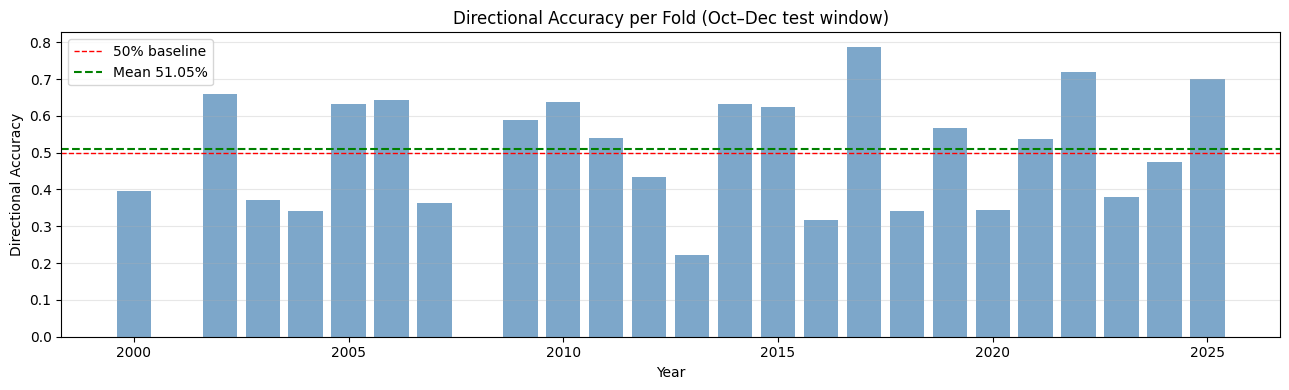

In [17]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',     label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual Δspread')
ax.set_ylabel('Predicted Δspread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='XGB predicted', lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct–Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

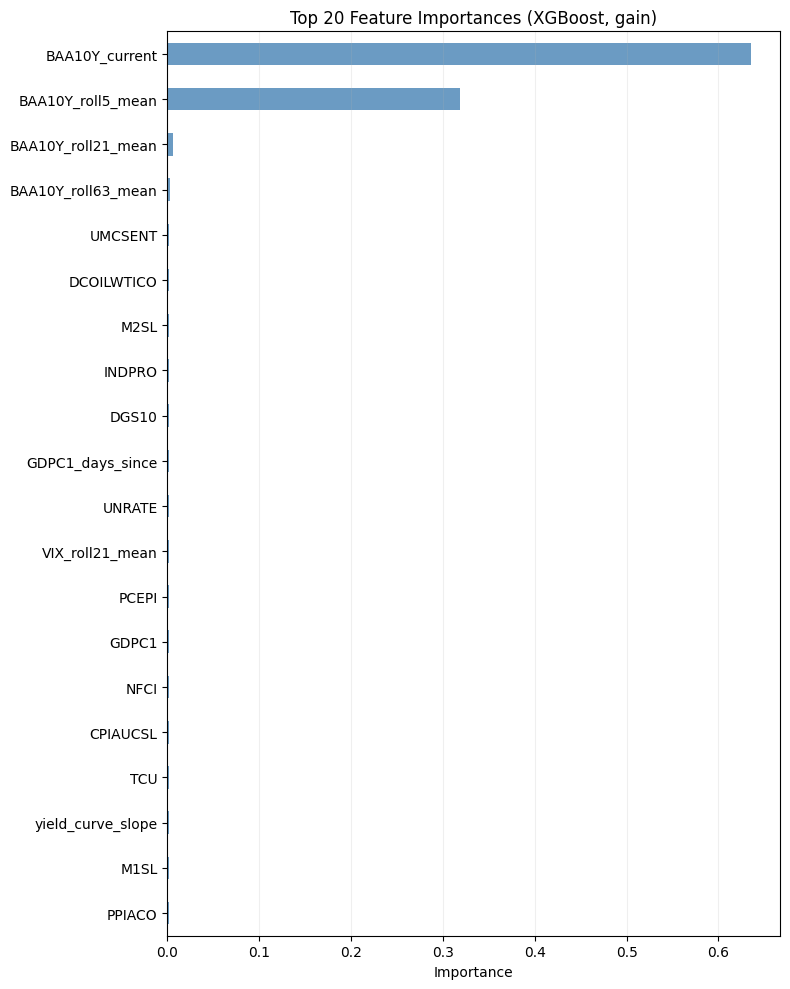

In [18]:
xgb_full = xgb.XGBRegressor(
    n_estimators=best_n,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_full.fit(X, y)

importances = pd.Series(xgb_full.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
importances.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 20 Feature Importances (XGBoost, gain)')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

## 28-day Horizon

In [19]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [20]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 28

# Supervised setup: features at time t predict BAA10Y at time t+H.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where either the current spread (needed for naive baseline)
# or the future spread (the target) is NaN.
mask = y_future.notna() & y_now.notna()
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

Horizon H = 28 day(s)
Samples: 11659  (1990-01-02 → 2025-12-04)


In [21]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end   = pd.Timestamp(f"{year}-09-30")
    test_start  = pd.Timestamp(f"{year}-10-01")
    test_end    = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':      year,
            'X_train':   X.loc[train_mask],
            'y_train':   y.loc[train_mask],
            'X_test':    X.loc[test_mask],
            'y_test':    y.loc[test_mask],
            'y_t_test':  y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train 1990-01-02 → 2000-09-30 (3559 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train 1990-01-02 → 2002-09-30 (4014 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train 1990-01-02 → 2003-09-30 (4379 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train 1995-10-01 → 2025-09-30 (9862 rows) | test 2025-10-01 → 2025-12-04 (65 rows)


Best n_estimators (boosting rounds): 43



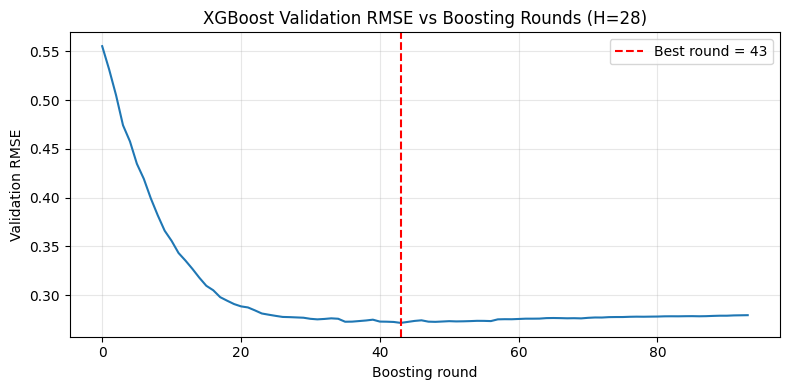

In [22]:
# Sweep n_estimators (number of boosting rounds) on the first fold using
# early stopping — the XGBoost equivalent of the RF OOB sweep.
# We use a small validation slice (last 20% of training) to drive early stopping.

X_sweep = folds[0]['X_train']
y_sweep = folds[0]['y_train']

val_cut  = int(len(X_sweep) * 0.80)
X_tr_sw  = X_sweep.iloc[:val_cut]
y_tr_sw  = y_sweep.iloc[:val_cut]
X_val_sw = X_sweep.iloc[val_cut:]
y_val_sw = y_sweep.iloc[val_cut:]

sweep_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
)
sweep_model.fit(
    X_tr_sw, y_tr_sw,
    eval_set=[(X_val_sw, y_val_sw)],
    verbose=False,
)

best_n = sweep_model.best_iteration
print(f"Best n_estimators (boosting rounds): {best_n}\n")

# Plot validation RMSE curve
results = sweep_model.evals_result()
val_rmse = results['validation_0']['rmse']

plt.figure(figsize=(8, 4))
plt.plot(val_rmse)
plt.axvline(best_n, color='red', linestyle='--', label=f'Best round = {best_n}')
plt.xlabel('Boosting round')
plt.ylabel('Validation RMSE')
plt.title(f'XGBoost Validation RMSE vs Boosting Rounds (H={H})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
fold_results = []
all_y_test   = []
all_y_pred   = []
all_y_curr   = []

for fold in folds:
    xgb_fold = xgb.XGBRegressor(
        n_estimators=best_n,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_fold.fit(fold['X_train'], fold['y_train'])

    y_pred_fold = pd.Series(xgb_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true      = fold['y_test']
    y_curr      = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir   = np.sign(y_true.values  - y_curr.values)
    pred_dir  = np.sign(y_pred_fold.values - y_curr.values)
    non_flat  = act_dir != 0
    dir_acc   = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_XGB': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)

    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R\u00b2={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all   = pd.concat(all_y_test)
y_pred_all   = pd.concat(all_y_pred)
y_curr_all   = pd.concat(all_y_curr)
results_df   = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE XGB':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_XGB'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

2000: MAE=0.2432 (naive=0.1497)  RMSE=0.2775  R²=-2.931  DirAcc=38.04%
2002: MAE=0.0954 (naive=0.1652)  RMSE=0.1190  R²= 0.326  DirAcc=86.96%
2003: MAE=0.0773 (naive=0.0508)  RMSE=0.0890  R²=-7.396  DirAcc=80.00%
2004: MAE=0.1396 (naive=0.0927)  RMSE=0.1542  R²=-1.780  DirAcc=14.61%
2005: MAE=0.0361 (naive=0.0358)  RMSE=0.0422  R²=-1.126  DirAcc=77.65%
2006: MAE=0.1145 (naive=0.0665)  RMSE=0.1189  R²=-12.612  DirAcc=30.77%
2007: MAE=0.3826 (naive=0.2942)  RMSE=0.4086  R²=-0.874  DirAcc=2.22%
2009: MAE=0.2217 (naive=0.1624)  RMSE=0.2620  R²=-1.021  DirAcc=74.71%
2010: MAE=0.1575 (naive=0.1642)  RMSE=0.1845  R²= 0.286  DirAcc=70.79%
2011: MAE=0.1623 (naive=0.1157)  RMSE=0.1852  R²=-3.704  DirAcc=45.56%
2012: MAE=0.0473 (naive=0.1118)  RMSE=0.0627  R²=-0.077  DirAcc=95.40%
2013: MAE=0.1439 (naive=0.1176)  RMSE=0.1816  R²=-0.471  DirAcc=53.33%
2014: MAE=0.0503 (naive=0.0652)  RMSE=0.0613  R²= 0.116  DirAcc=71.11%
2015: MAE=0.1714 (naive=0.0752)  RMSE=0.1843  R²=-4.021  DirAcc=38.55%
2016: 

In [24]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat       = actual_direction != 0
dir_acc_xgb    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive  = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  XGB model : {dir_acc_xgb:.2%}")
print(f"  Naive     : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): XGB correct "
      f"{(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

Overall directional accuracy across all folds (excl. flat moves, n=2109):
  XGB model : 52.30%
  Naive     : 0.00%

Breakdown by actual direction:
  Actual UP   ( 792 days): XGB correct 50.51%
  Actual DOWN (1317 days): XGB correct 53.38%


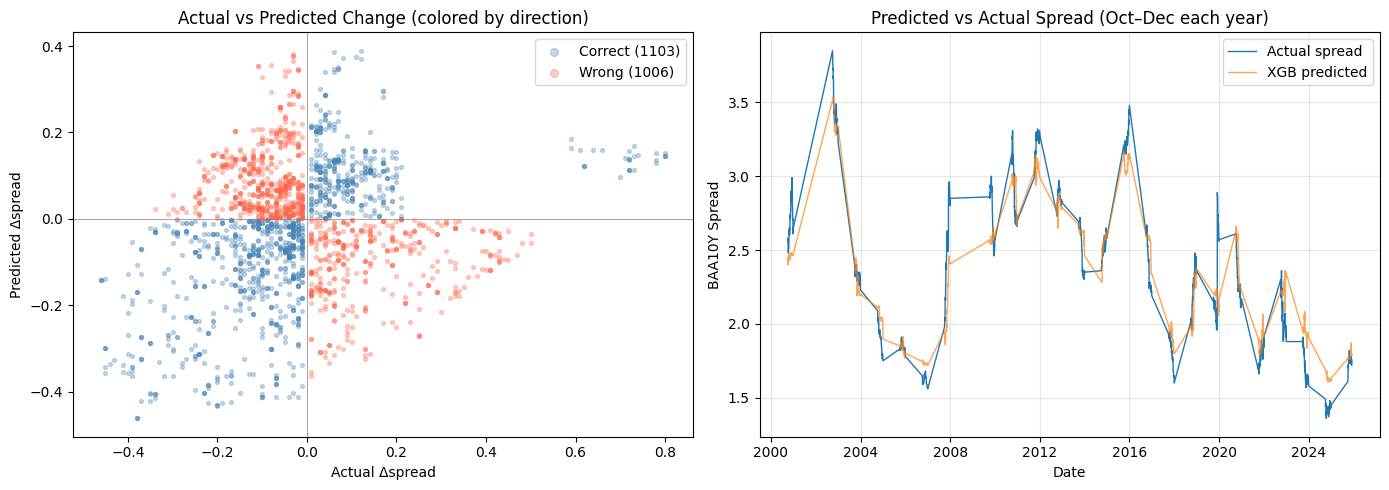

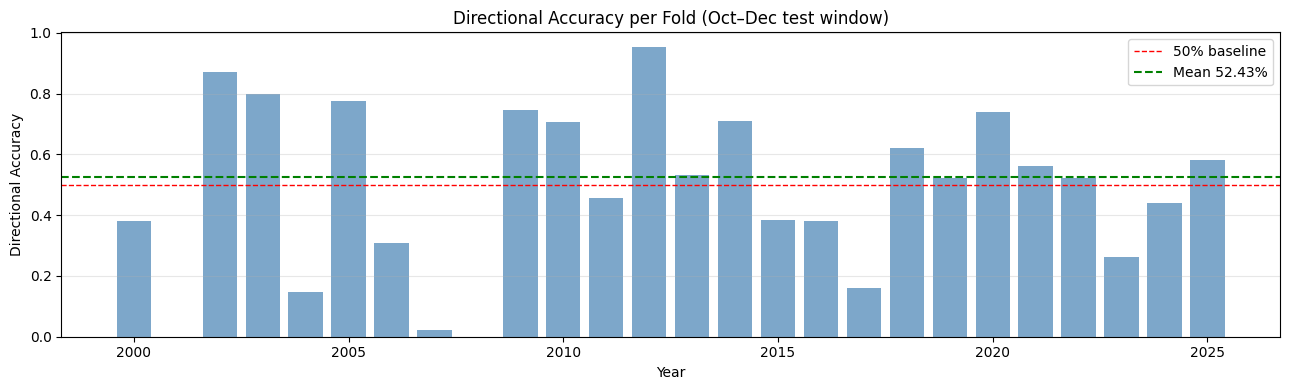

In [25]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',     label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual Δspread')
ax.set_ylabel('Predicted Δspread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='XGB predicted', lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct–Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct–Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

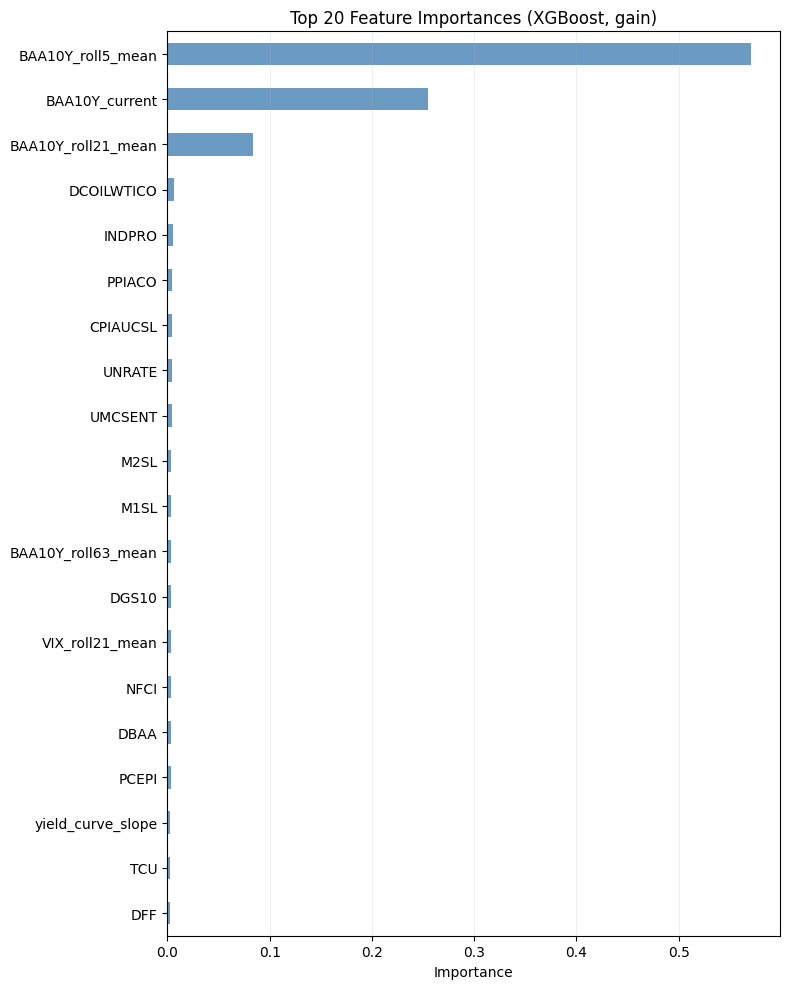

In [26]:
xgb_full = xgb.XGBRegressor(
    n_estimators=best_n,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_full.fit(X, y)

importances = pd.Series(xgb_full.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
importances.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Top 20 Feature Importances (XGBoost, gain)')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()